# Modules

In [1]:
# Import required libraries
from Pfitting_utility import *
import pickle
from natsort import natsorted

In [2]:
%load_ext autoreload
%autoreload 2

# Data

In [3]:
### Get data

sel_le = 'LE1'    # arbitrary labelling as LEs found -- LE1 has cleanest peaks so good to test code on
# sel_le = 'LE2'
# sel_le = 'LE3'
ddir = f"../profiles/Greebo/{sel_le}/f444w"

df_files = natsorted(glob.glob(f"{ddir}/tables/df*"))
gp_files = natsorted(glob.glob(f"{ddir}/tables/gp*"))

data_ls = [pd.read_csv(df_dir) for df_dir in df_files]
gp_ls = [pd.read_csv(gp_dir) for gp_dir in gp_files]

In [4]:
### for plotting
colorblind_colors = ['#0173B2', '#DE8F05', '#CC78BC', '#CA9161', '#949494','#ECE133', '#56B4E9', '#009E73', '#F0E442', '#D55E00','#E69F00', '#029E73', '#56B4E9', '#CC79A7', '#999999']
recommended_colors = [
    '#1f77b4',  # Muted blue
    '#ff7f0e',  # Safety orange
    '#2ca02c',  # Cooked asparagus green
    '#d62728',  # Brick red
    '#9467bd',  # Muted purple
    '#8c564b',  # Chestnut brown
    '#e377c2',  # Raspberry yogurt pink
    '#7f7f7f',  # Middle gray
    '#bcbd22',  # Curry yellow-green
    '#17becf',  # Blue-teal
    '#aec7e8',  # Light blue
    '#ffbb78',  # Light orange
    '#98df8a',  # Light green
    '#ff9896',  # Light red
    '#c5b0d5'   # Light purple
]

In [5]:
### Model example
### Using piece wise exponential functional form to describe light curve

# t_range = np.linspace(-20,20,1000)
# func_t = piece_wise(t_range, 0.0, 0.5, 2.0)

# plt.plot(t_range, func_t)
# rt, dt = get_hwhm(t_range, func_t, plot=False)
# print(rt, dt)

# Fitting Process

## Testing emcee code

In [6]:
# test_r, test_d = 0.1, 1.0
# # test_r, test_d = None, None
# test_nuis = False
# # test_nuis = True
# test = emcee_fit(fit_data, test_r, test_d, fit4nuisance=test_nuis)

In [7]:
# plot_emcee(test, fit_data, test_r, test_d, fit4nuisance=test_nuis)

In [8]:
# if test_r is not None:
#     if test_nuis is False:
#         labels_t = ['sigma','t0']
#     elif test_nuis is True:
#         labels_t = ['sigma','t0', 'A', 'B']
# elif test_r is None:
#     if test_nuis is False:
#         labels_t = ['sigma','t0', 'hwhm_rise', 'hwhm_delta']
#     elif test_nuis is True:
#         labels_t = ['sigma','t0', 'hwhm_rise', 'hwhm_delta', 'A', 'B']

# corner.corner(test, labels=labels_t)

## Emcee fitting - Grid Approach

In [9]:
### Select image to do peak fitting on LE

if sel_le == 'LE1': sel_ind = 4
if sel_le == 'LE2': sel_ind = 3
if sel_le == 'LE3': sel_ind = 5
    
fit_data = data_ls[sel_ind]

In [10]:
### Define grid of rise and fall times to run fitting process

fit_trises = [1./24., 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
fit_tfalls = []
fit_tdeltas = np.arange(0.05, 7.25, 0.25)

for ftr in fit_trises:
    temp_tfalls = ftr+fit_tdeltas
    fit_tfalls.append(temp_tfalls)

In [11]:
### Run through process and save fitting results -- takes a lot of memory so may crash so rerun

# # em_sampss = []

# for ftr in fit_trises:
#     # em_samps = []
#     for ftd in fit_tdeltas:
#         # em_samp = emcee_fit(fit_data, ftr, ftd)
#         # em_samps.append(em_samp)
#     # em_sampss.append(em_samps)
#         if os.path.isfile(f'{ddir}/fitting_params/emcee-grid/run_{ftr}_{ftd}.pkl') is False:     # can't run over all grid at once, so skip ones that did run
#             em_samp = emcee_fit(fit_data, ftr, ftd)
#             with open(f'{ddir}/fitting_params/grid/run_{ftr}_{ftd}.pkl', 'wb') as f:
#                 pickle.dump(em_samp, f)

In [12]:
### Read in fitting results

em_sampss = []
for ftr in fit_trises:
    em_samps = []
    for ftd in fit_tdeltas:
        with open(f'{ddir}/fitting_params/emcee-grid/run_{ftr}_{ftd}.pkl', 'rb') as f:
            em_samp = pickle.load(f)
            em_samps.append(em_samp)
    em_sampss.append(em_samps)

sigma: 10.68 +0.29 -0.28
t0: -0.47 +0.20 -0.20
A: 69.90969484023624,   B:0.013517124949469604
Ave resids: 8.676211546160721e-05
sigma: 9.10 +0.35 -0.34
t0: -7.74 +0.20 -0.21
A: 1.700399135429094,   B:-0.007141728457219246
Ave resids: 0.0009059946905623663


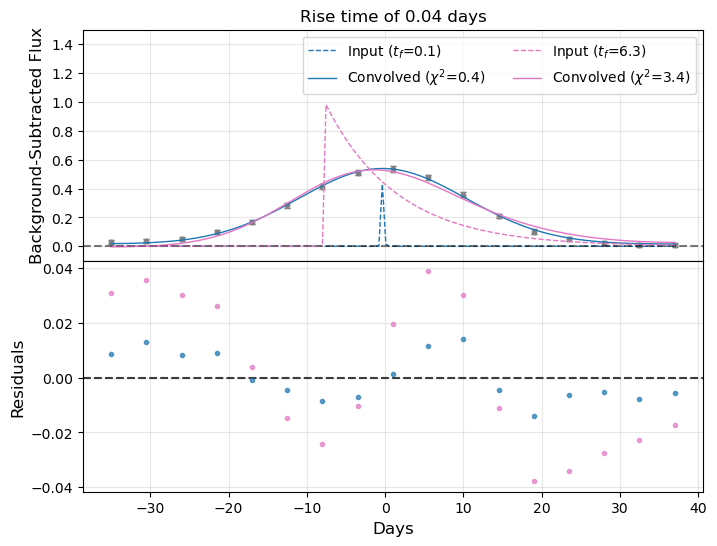

sigma: 10.68 +0.29 -0.28
t0: -0.47 +0.20 -0.20
A: 10.701193811137955,   B:0.013013457545711413
Ave resids: 9.098049579313123e-05
sigma: 9.10 +0.35 -0.34
t0: -7.74 +0.20 -0.21
A: 1.5482186496044221,   B:-0.011838708932159929
Ave resids: 0.0010920001399823461


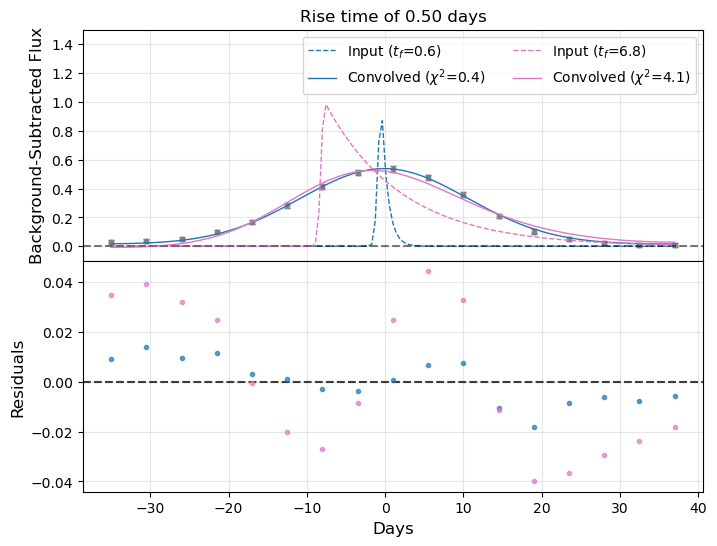

sigma: 10.68 +0.29 -0.28
t0: -0.47 +0.20 -0.20
A: 5.509109405541992,   B:0.011721957767945069
Ave resids: 0.00014748176903598895
sigma: 9.10 +0.35 -0.34
t0: -7.74 +0.20 -0.21
A: 1.416816733457001,   B:-0.0170400256253697
Ave resids: 0.0013162169821106962


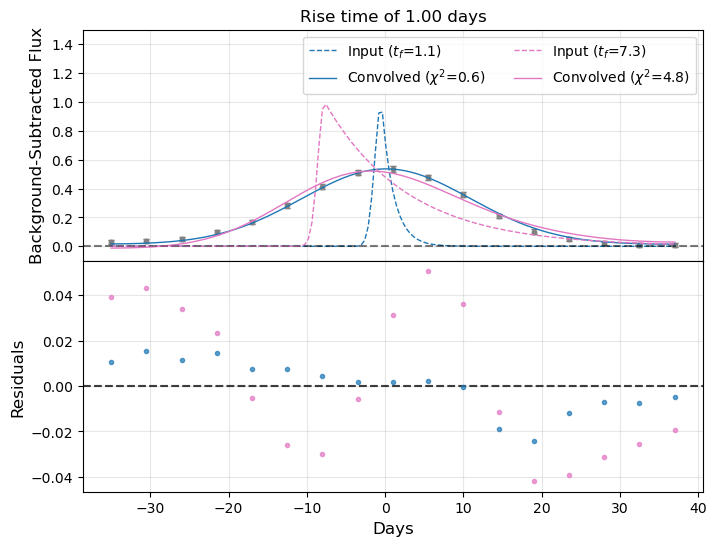

sigma: 10.68 +0.29 -0.28
t0: -0.47 +0.20 -0.20
A: 3.7431640703193447,   B:0.009666662700876861
Ave resids: 0.00025893655266408927
sigma: 9.10 +0.35 -0.34
t0: -7.74 +0.20 -0.21
A: 1.3123720529304919,   B:-0.022335893482899445
Ave resids: 0.0015601585356290156


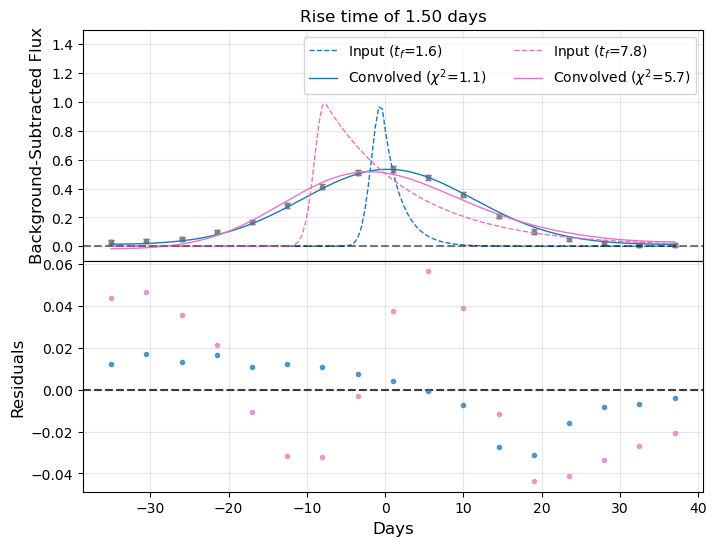

sigma: 10.68 +0.29 -0.28
t0: -0.47 +0.20 -0.20
A: 2.8589703198632717,   B:0.006870589392653832
Ave resids: 0.00041811737998510373
sigma: 9.10 +0.35 -0.34
t0: -7.74 +0.20 -0.21
A: 1.2275526244859059,   B:-0.02772374082148848
Ave resids: 0.001821553971903087


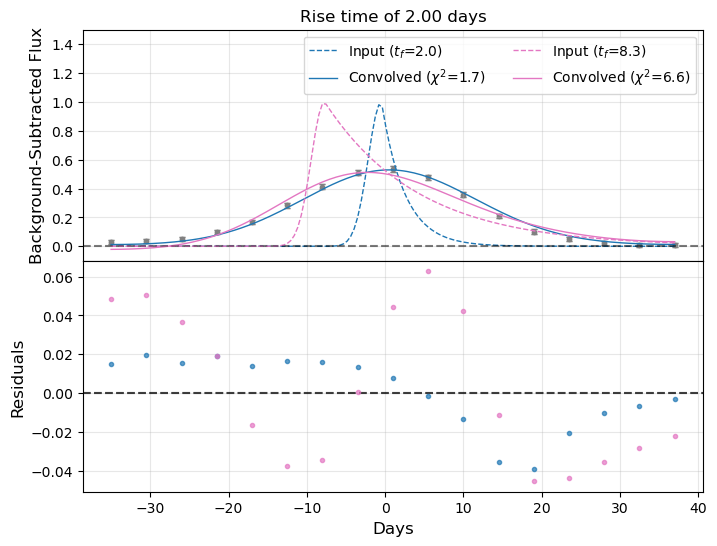

sigma: 10.68 +0.29 -0.28
t0: -0.47 +0.20 -0.20
A: 2.332496875521651,   B:0.003359660274630684
Ave resids: 0.0006157842925293385
sigma: 9.10 +0.35 -0.34
t0: -7.74 +0.20 -0.21
A: 1.1575773573229504,   B:-0.0332092514475688
Ave resids: 0.002097923363698111


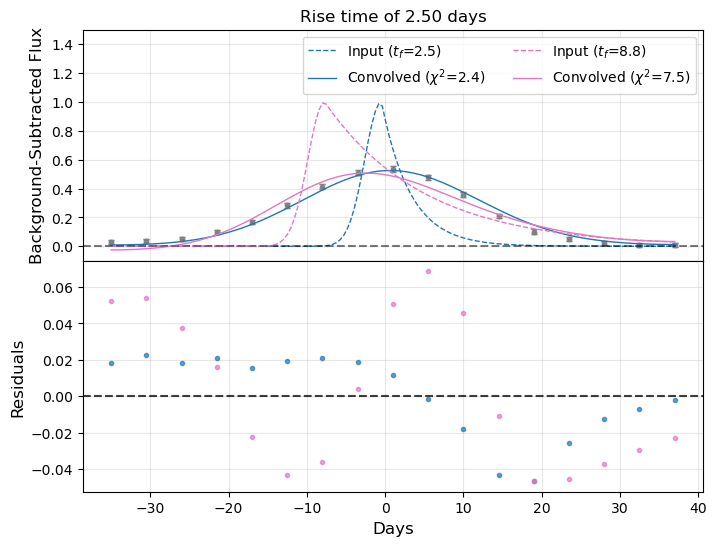

sigma: 10.68 +0.29 -0.28
t0: -0.47 +0.20 -0.20
A: 1.986157161421184,   B:-0.0008216160939055467
Ave resids: 0.0008427549859481876
sigma: 9.10 +0.35 -0.34
t0: -7.74 +0.20 -0.21
A: 1.099147933186057,   B:-0.038805178573548614
Ave resids: 0.002386604527564266


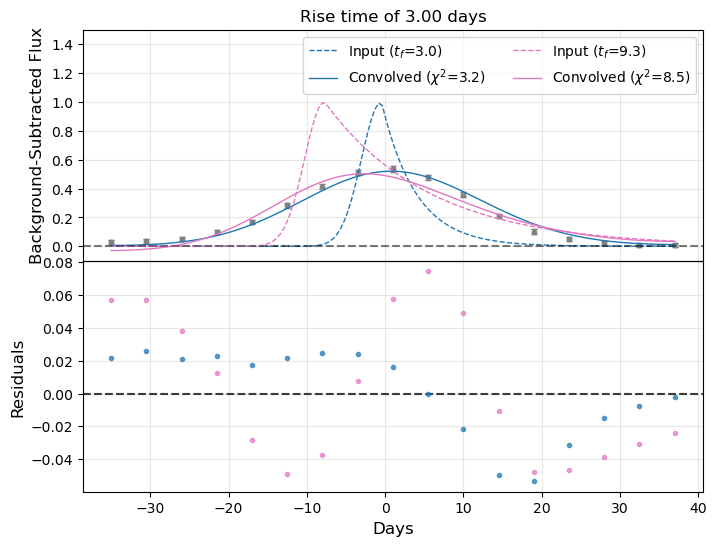

sigma: 10.68 +0.29 -0.28
t0: -0.47 +0.20 -0.20
A: 1.742978849756993,   B:-0.005603168326870127
Ave resids: 0.0010910987699737711
sigma: 9.10 +0.35 -0.34
t0: -7.74 +0.20 -0.21
A: 1.0499205102859646,   B:-0.04453079567432334
Ave resids: 0.002684764950510226


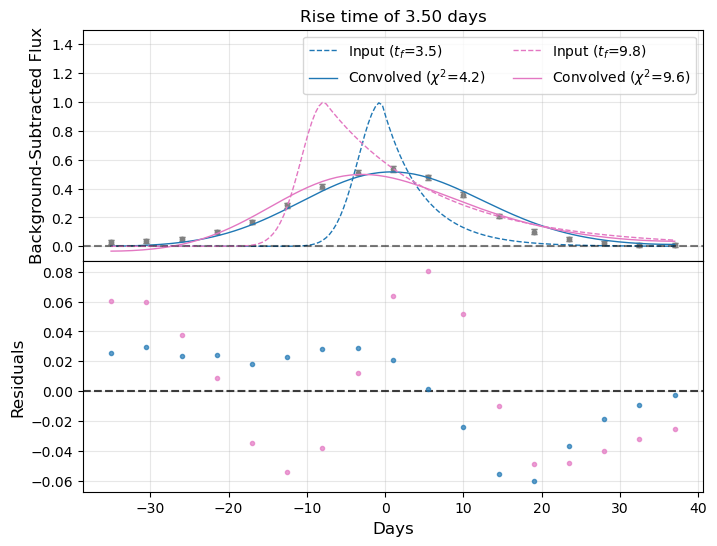

sigma: 10.68 +0.29 -0.28
t0: -0.47 +0.20 -0.20
A: 1.5641503680911777,   B:-0.010897622640437239
Ave resids: 0.0013544286038492212
sigma: 9.10 +0.35 -0.34
t0: -7.74 +0.20 -0.21
A: 1.0081911792296765,   B:-0.05041144059287284
Ave resids: 0.0029894263667097267


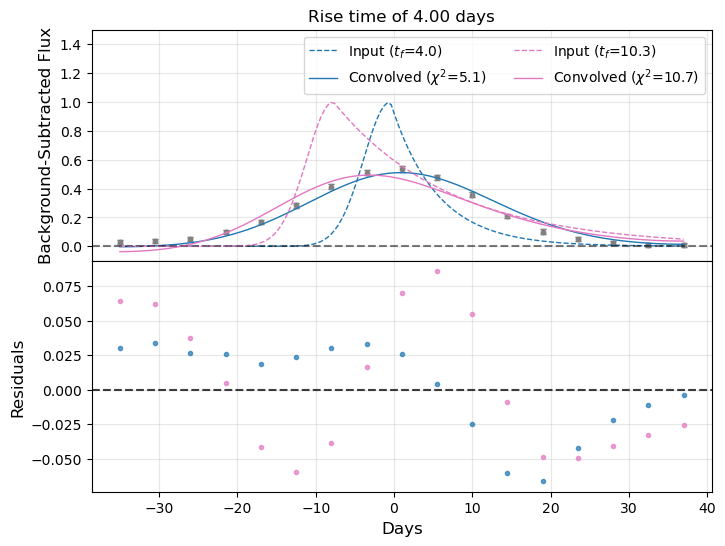

sigma: 10.68 +0.29 -0.28
t0: -0.47 +0.20 -0.20
A: 1.4280006780655456,   B:-0.016615179780812356
Ave resids: 0.0016276299721528214
sigma: 9.10 +0.35 -0.34
t0: -7.74 +0.20 -0.21
A: 0.9726983194793668,   B:-0.056478083797990096
Ave resids: 0.0032975060521317264


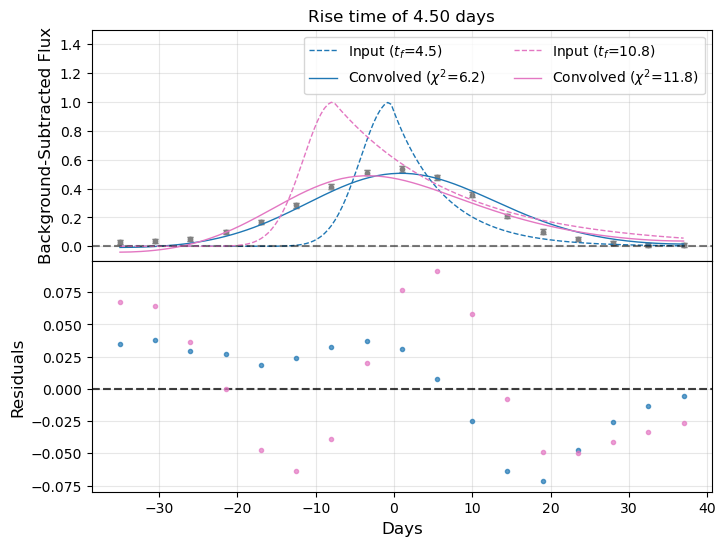

sigma: 10.68 +0.29 -0.28
t0: -0.47 +0.20 -0.20
A: 1.3215206106359276,   B:-0.022676126947918936
Ave resids: 0.001906428525171224
sigma: 9.10 +0.35 -0.34
t0: -7.74 +0.20 -0.21
A: 0.9424936216003454,   B:-0.06276688061384371
Ave resids: 0.003605876622237624


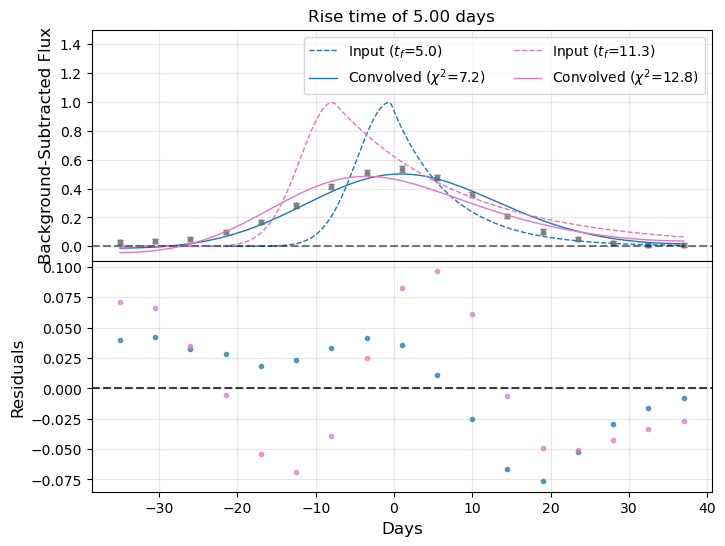

In [13]:
### Plot fitting results

for i in range(len(fit_trises)):
    one_fig, one_axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    one_axs = one_axs.flatten()
    for j, em in enumerate(em_sampss[0]):
        # if j==0 or j==8 or j==15 or j==25:
        if j==0 or j==25:
            plot_emcee(em, fit_data, fit_trises[i], fit_tdeltas[j], figure=[one_fig,one_axs], color_q=recommended_colors[j//4])
    plt.show()

In [14]:
### Get reduced chi^2 of the fits

# chi2_lss = []
# for i, ems in enumerate(em_sampss):
#     chi2_ls = []
#     for j, em in enumerate(ems):
#         params_res, chi2_res, resids = emcee_results(em, fit_data, fit_trises[i], fit_tdeltas[j])
#         chi2_ls.append(chi2_res)
#     chi2_lss.append(chi2_ls)

In [15]:
### Calculate the p-values of the chi^2's

# dof_i = len(fit_data) - 2

# p_valss = []
# p_cutoffs = []
# for i, chi2s in enumerate(chi2_lss):
#     p_vals = calc_pvalchi2(chi2s, dof_i, fit_tfalls[i])
#     p_valss.append(p_vals)

#     pval_f = interp1d(fit_tfalls[i], p_vals)
#     proot = find_root(pval_f, 0.05, [min(fit_tfalls[i]),max(fit_tfalls[i])])
#     p_cutoffs.append(proot)

In [16]:
### Plot chi2's on grid of rise and fall times

# max_tdur = fit_trises[-1] + fit_tfalls[-1][-1]

# dof_i = len(fit_data) - 2
# chi2_16th = sc_chi2.ppf(0.16, dof_i)/dof_i
# chi2_50th = sc_chi2.ppf(0.5, dof_i)/dof_i
# chi2_90th = sc_chi2.ppf(0.9, dof_i)/dof_i

# colorst = ['red', 'blue', 'green']

# import matplotlib.colors as mcolors
# norm = mcolors.Normalize(vmin=1.0, vmax=2.0)

# for i in range(len(em_sampss)):
#     plt.scatter([fit_trises[i]]*len(fit_tfalls[i]), fit_tfalls[i], c=chi2_lss[i], norm=norm)

# plt.axline((0,0),slope=1.0, color='k', ls='--', alpha=0.5)
# plt.colorbar(label='$\chi^2$')

# plt.xlabel('Rise time (days)')
# plt.ylabel('Fall time (days)')
# # plt.ylabel('Delta (days)')

# # plt.savefig(f"{ddir}/plots/fallvrise_chi2grid(1).png", bbox_inches = 'tight', dpi=100)

In [17]:
### Plot p-values on grid of rise and fall times

# norm = mcolors.Normalize(vmin=0.0, vmax=1.0)

# for i in range(len(em_sampss)):
#     plt.scatter([fit_trises[i]]*len(fit_tfalls[i]), fit_tfalls[i], c=p_valss[i], norm=norm, cmap='viridis_r')

# plt.axline((0,0),slope=1.0, color='k', ls='--', alpha=0.5)

# plt.colorbar(label='$p-value$')

# plt.xlabel('Rise time (days)')
# plt.ylabel('Fall time (days)')
# # plt.ylabel('Delta (days)')

# plt.legend()

# # plt.savefig(f"{ddir}/plots/fallvrise_pvalgrid(1).png", bbox_inches = 'tight', dpi=100)

In [18]:
### Plot chi2's per rise time

# n_plots = len(em_sampss)
# fig, axs = plt.subplots(n_plots//3+1, 3, figsize=(12, n_plots//3*4))
# axs = axs.flatten()
# for i in range(len(em_sampss)):
#     ax = axs[i]
#     ax.plot(fit_tfalls[i], chi2_lss[i], ls='-', marker='o', color='royalblue')
#     ax.set_ylabel('Reduced $\\chi^2$', fontsize=10)
#     ax.set_xlabel('Fall Time (days)', fontsize=10)
#     ax.set_title(f"Rise Time = {fit_trises[i]:.2f} days", fontsize=12)
#     ax.axhline(min(chi2_lss[i])+chi2_90th, color='red')
#     chi2_f = interp1d(fit_tfalls[i], chi2_lss[i])

#     cutoff = min(chi2_lss[i]) + chi2_90th
#     root = find_root(chi2_f, cutoff, [min(fit_tfalls[i]), max(fit_tfalls[i])])
#     ax.axvline(root, color='red', label=f"{root:.2f} days")
            
#     ax.legend(loc=2)
# fig.subplots_adjust(wspace=0.25, hspace=0.4)

# # fig.savefig(f'{ddir}/plots/fallvrise_chi2s(1).png', bbox_inches = 'tight', dpi=100)

In [19]:
### Look at loglikelihood distribution

# for i, ftr in enumerate(fit_trises):
#     chi2_i = chi2_lss[i]
#     llike = -0.5*np.array(chi2_i)
#     llike_norm = np.exp(llike-llike.max())
#     plt.scatter(fit_tfalls[i], llike_norm)
    
#     ll_cut = 0.75
#     ll_f = interp1d(fit_tfalls[i], llike_norm)
#     x_cut = opt.fsolve(lambda x: ll_f(x) - ll_cut, x0=5.5)[0]
#     plt.axhline(ll_cut, color='k')
#     plt.axvline(x_cut, color='k')
    
#     plt.title(f'Rise time of {ftr:.2f}')
#     plt.xlabel('Fall time (days)')
#     plt.ylabel('Normalized Likelihood')
#     plt.show()

In [20]:
### Better visualize comparison of fall times

# one_fig, one_axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
# one_axs = one_axs.flatten()
# for j, em in enumerate(em_sampss[0]):
#     if j==0 or j==8 or j==15 or j==25:
#         plot_emcee(em, fit_data, fit_trises[0], fit_tdeltas[j], figure=[one_fig,one_axs], color_q=recommended_colors[j//4])

# # one_fig.savefig(f"{ddir}/plots/fits_plot(1).png", bbox_inches = 'tight', dpi=100)

In [21]:
### Check corner plots of fits

# for i, ems in enumerate(em_sampss):
#     if i == 0:
#         for j, em in enumerate(ems):
#             corner.corner(em, labels=['sigma','t0'], quantiles=[0.16, 0.5, 0.84], levels=[0.68, 0.95])
#             plt.show()

## Dynesty Approach

### Check all epochs

In [22]:
### Run the fitting process

# dyn_results = []
# for i, fdata in enumerate(data_ls):
#     dyn_res = dynesty_fit(fdata)
#     dyn_results.append(dyn_res)

#     epoch_label = fdata['obs_date'][0]
#     epoch_label = epoch_label.partition('T')[0].replace('-','')

#     with open(f'{ddir}/fitting_params/dynesty/results_{epoch_label}.pkl', 'wb') as f:
#         pickle.dump(dyn_res, f)

In [23]:
### read in previously saved runs

dyn_files = natsorted(glob.glob(f'{ddir}/fitting_params/dynesty/*.pkl'))
dyn_results = []
for fi in dyn_files:
    with open(fi, 'rb') as f:
        dyn_res = pickle.load(f)
        dyn_results.append(dyn_res)

0
------------------
HWHM trise: 0.56 +0.68 -0.40
HWHM tfall: 1.11 +0.64 -0.39
chi2: 0.769998497579411
8.560699476948762e-05


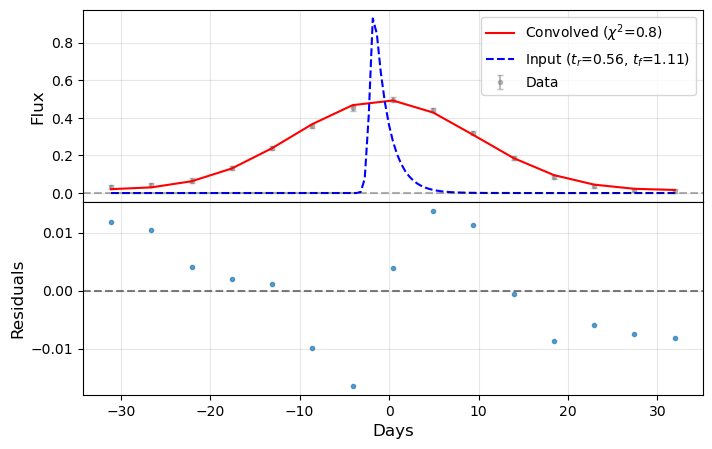

1
------------------
HWHM trise: 0.59 +0.72 -0.42
HWHM tfall: 1.18 +0.68 -0.43
chi2: 0.6783446896663231
9.767098972118179e-05


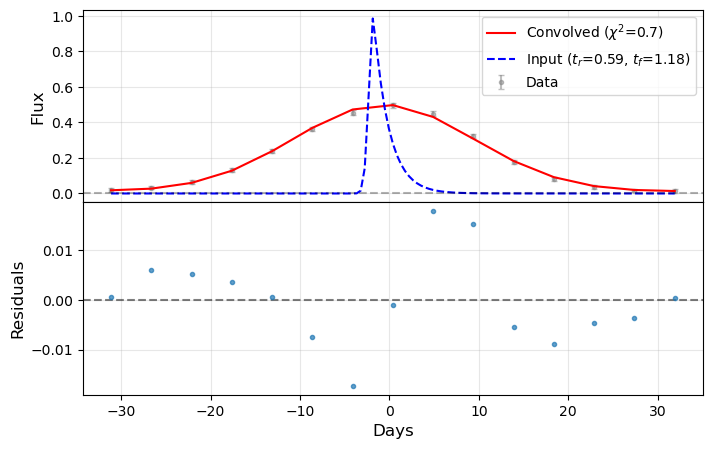

2
------------------
HWHM trise: 0.75 +0.90 -0.54
HWHM tfall: 1.52 +0.89 -0.55
chi2: 0.645295520278637
4.498692557133258e-05


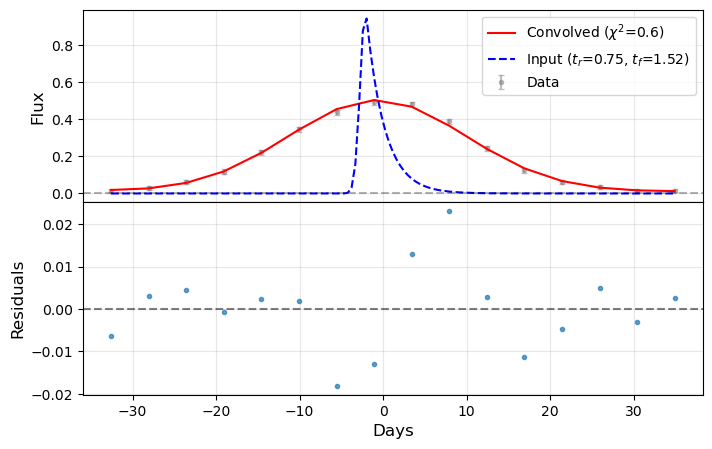

3
------------------
HWHM trise: 0.64 +0.78 -0.46
HWHM tfall: 1.29 +0.75 -0.47
chi2: 0.6952222974726114
0.0002442614799447001


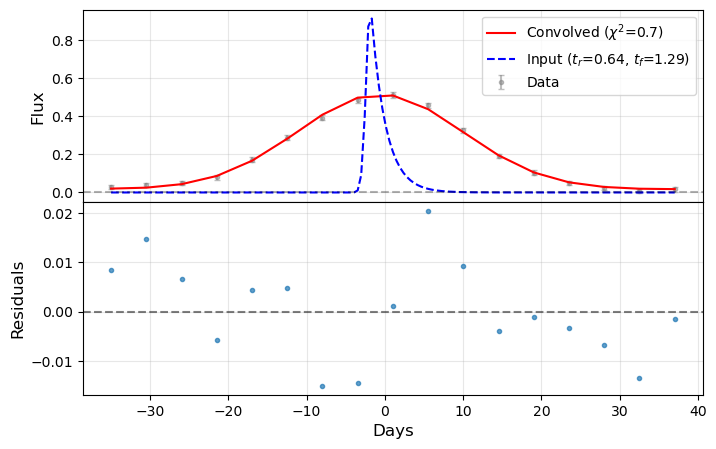

4
------------------
HWHM trise: 0.68 +0.80 -0.49
HWHM tfall: 1.35 +0.79 -0.48
chi2: 0.47053287848870273
8.978369282101557e-05


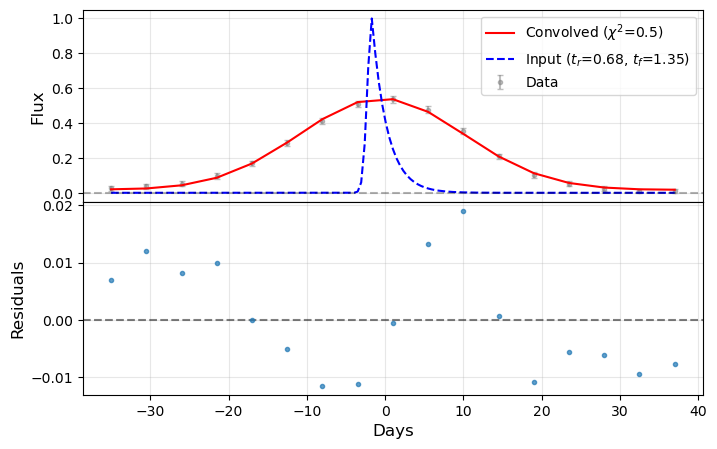

5
------------------
HWHM trise: 0.67 +0.78 -0.48
HWHM tfall: 1.37 +0.79 -0.51
chi2: 0.9194444134007446
0.0001626689435436111


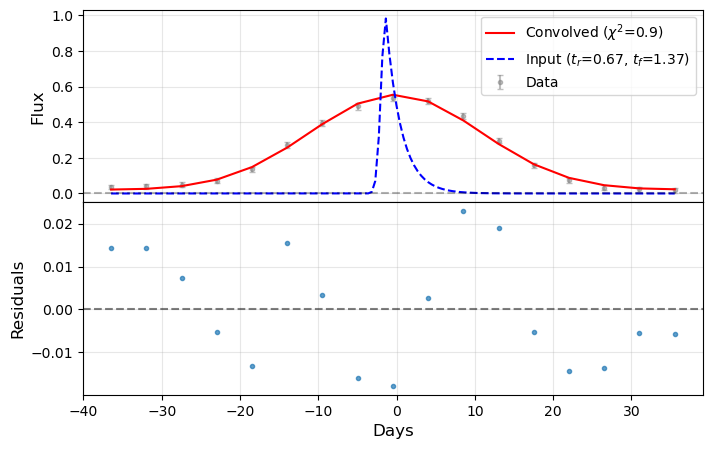

6
------------------
HWHM trise: 0.56 +0.69 -0.40
HWHM tfall: 1.13 +0.70 -0.41
chi2: 1.4967125855107166
0.0002107603217927021


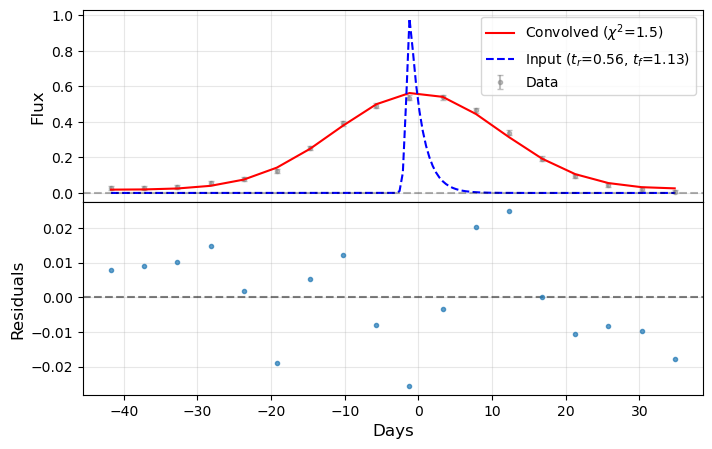

7
------------------
HWHM trise: 0.60 +0.70 -0.43
HWHM tfall: 1.21 +0.68 -0.44
chi2: 1.4770411399951544
0.00018518166369042947


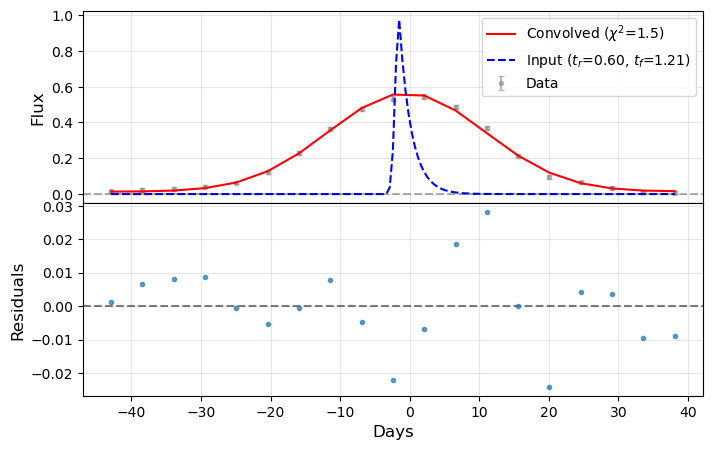

8
------------------
HWHM trise: 0.72 +0.85 -0.52
HWHM tfall: 1.42 +0.83 -0.51
chi2: 1.22331803837538
0.00016749033903523187


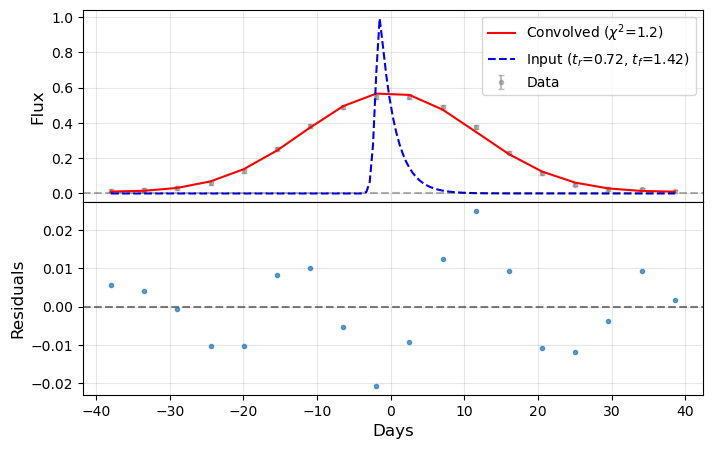

9
------------------
HWHM trise: 1.28 +1.20 -0.91
HWHM tfall: 2.55 +1.20 -0.90
chi2: 1.1079815528552872
0.00017773532306652854


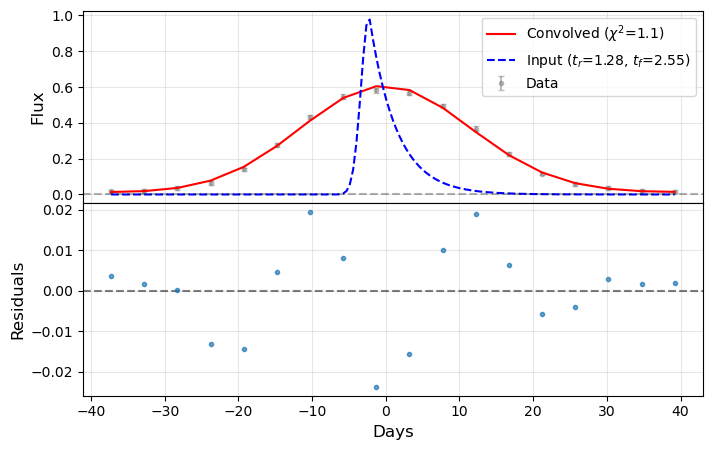

10
------------------
HWHM trise: 0.84 +0.92 -0.59
HWHM tfall: 1.67 +0.89 -0.59
chi2: 1.7593654922607542
0.00019581004138672915


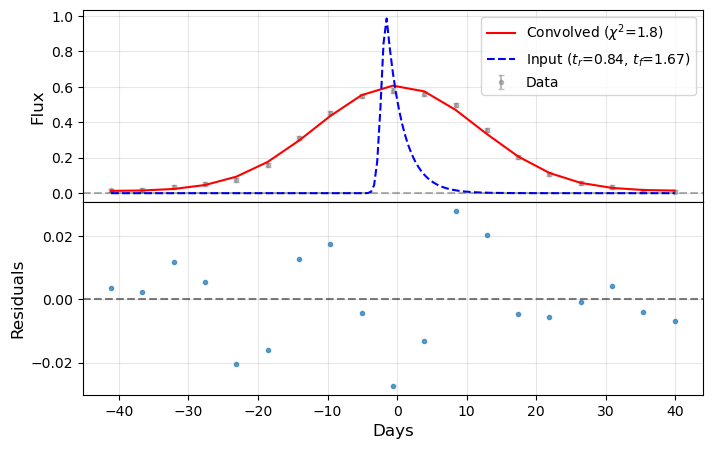

11
------------------
HWHM trise: 0.77 +0.87 -0.55
HWHM tfall: 1.51 +0.88 -0.53
chi2: 1.4922979954354745
0.00016425940062633578


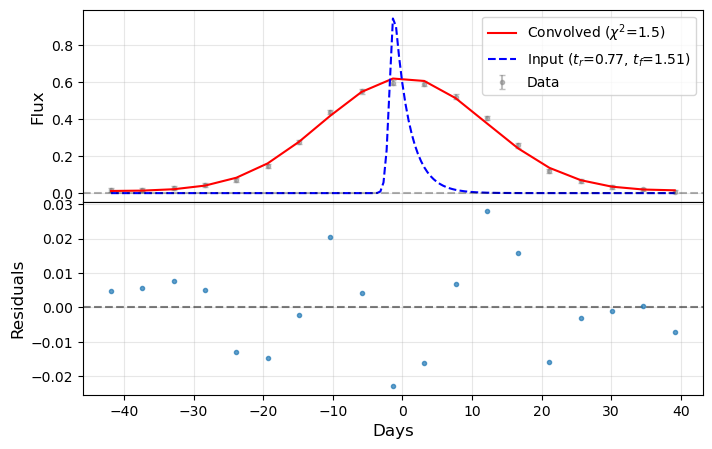

12
------------------
HWHM trise: 0.69 +0.81 -0.49
HWHM tfall: 1.39 +0.80 -0.50
chi2: 1.5617984128949287
0.0001736756738276308


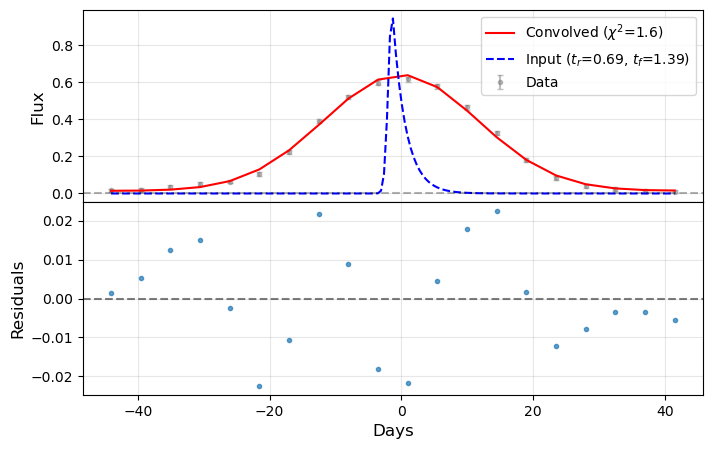

13
------------------
HWHM trise: 0.57 +0.68 -0.41
HWHM tfall: 1.13 +0.69 -0.42
chi2: 1.568406613436455
0.00014120794752110467


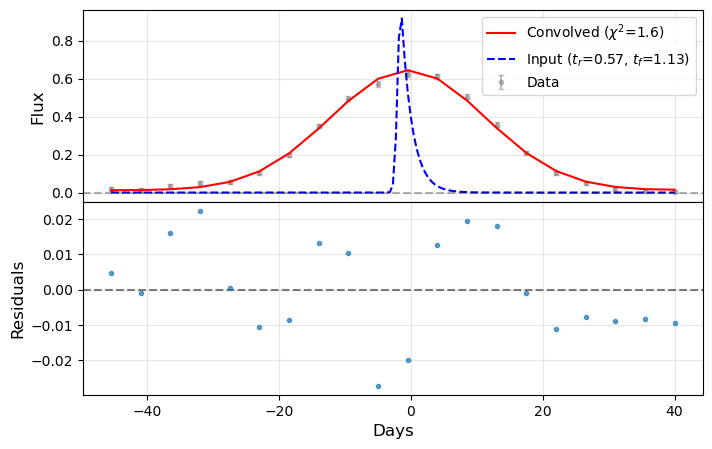

14
------------------
HWHM trise: 0.60 +0.71 -0.43
HWHM tfall: 1.21 +0.72 -0.44
chi2: 2.598181020388543
0.00018692211017196585


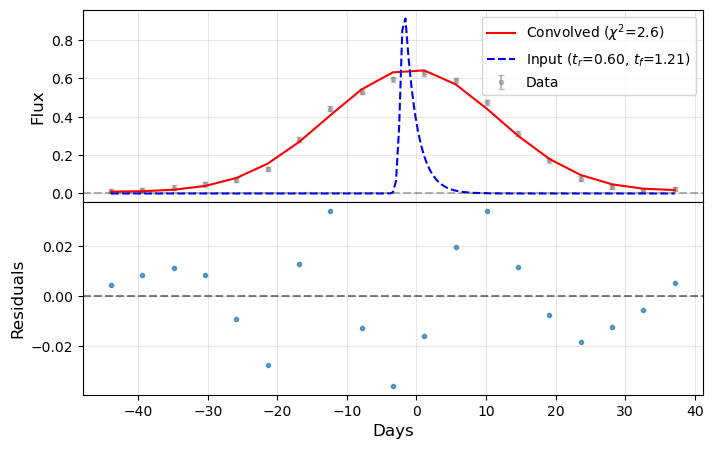

In [24]:
for i, dynres in enumerate(dyn_results):
    print(i)
    print(f"------------------")
    fdata = data_ls[i]
    fig_fit, ax_fit = plot_dynesty(dynres, fdata)
    plt.show()

In [25]:
# for i, dynres in enumerate(dyn_results):
#     print(i)
#     print(f"------------------")
#     fig = dyplot.cornerplot(dynres, labels=['hwhm_trise','hwhm_delta', 'sigma', 't0'], title_quantiles=[0.16, 0.5, 0.84], quantiles_2d=[0.68, 0.95, 0.997])
#     plt.show()

### Check Best Epoch

In [26]:
if sel_le == 'LE1': sel_epoch = '20250907'
if sel_le == 'LE2': sel_epoch = '20250824'
if sel_le == 'LE3': sel_epoch = '20250923'
    
with open(f'{ddir}/fitting_params/dynesty/results_{sel_epoch}.pkl', 'rb') as f:
    dynres_c= pickle.load(f)

fit_data = data_ls[sel_ind]

In [27]:
# weights = np.exp(dynres_c.logwt - dynres_c.logz[-1])
# weights /= sum(weights)
# samples_equal = dynesty.utils.resample_equal(dynres_c.samples, weights)

HWHM trise: 0.67 +0.80 -0.48
HWHM tfall: 1.34 +0.80 -0.48
chi2: 0.46967779187174474
8.945643904618913e-05


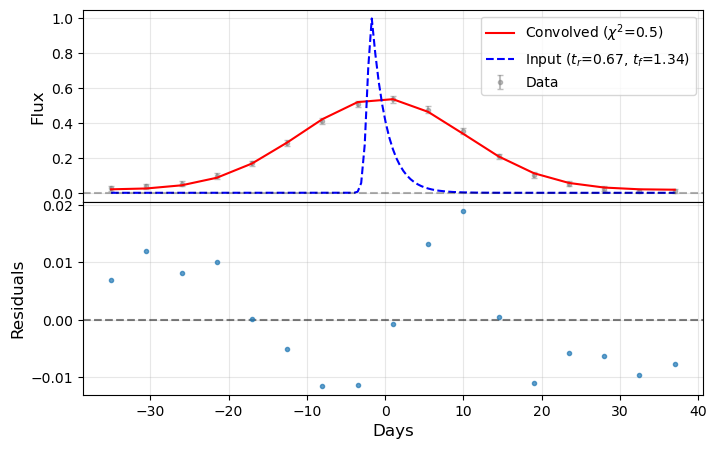

In [28]:
fig_fit, ax_fit = plot_dynesty(dynres_c, fit_data)
fig_fit.savefig(f'{ddir}/plots/dynfit_{sel_epoch}.png', bbox_inches = 'tight', dpi=100)

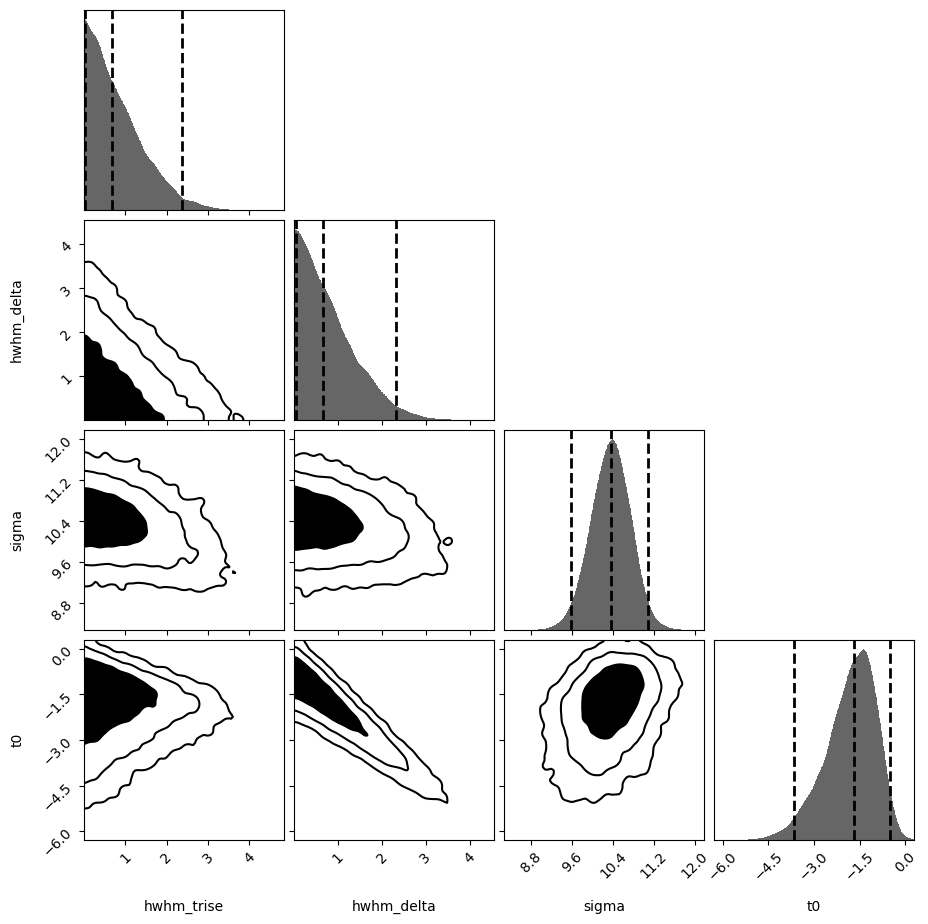

In [29]:
fig = dyplot.cornerplot(dynres_c, labels=['hwhm_trise','hwhm_delta', 'sigma', 't0'], title_quantiles=[0.16, 0.5, 0.84], quantiles_2d=[0.68, 0.95, 0.997])
fig[0].savefig(f'{ddir}/plots/dynres_{sel_epoch}.png', bbox_inches = 'tight', dpi=100)

## Simultaneous Multiple-Peak Approach

In [30]:
# simul_fit = simul_emcee(data_ls[3:6])

In [31]:
# plot_simul(simul_fit, data_ls[3:6])

In [32]:
# corner.corner(simul_fit, labels=['hwhm_rise', 'hwhm_delta', 'sigma', 't0'], show_titles=True, title_fmt=".3f")